### Visualize calcium traces and spike trains

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pickle import load

try:
    from c2s import preprocess
except ImportError:
    pass

In [3]:
%matplotlib inline

In [4]:
dataset = 'data.1.train.preprocessed.pck'  # AOD dataset
width = 10
height = 0 # auto
cells = [1, 5] # which cells to plot
offset = 0
seconds = 100 # length of visualized trace
dpi = 100 # figure resolution

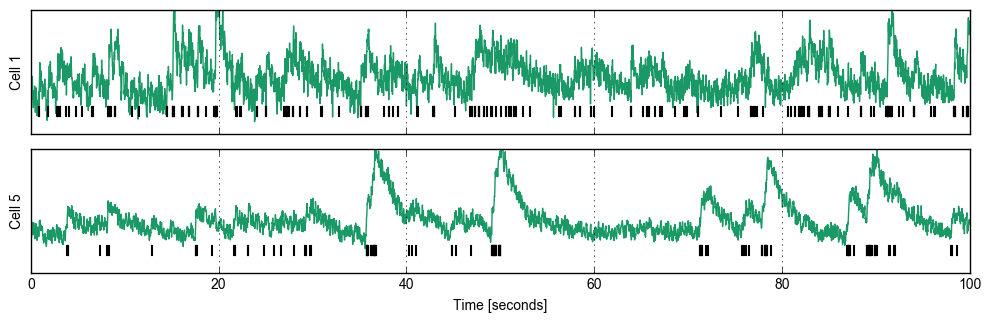

In [5]:
with open(dataset, 'rb') as handle:
    data = load(handle, encoding='latin1')
data = [data[c - 1] for c in cells]

try:
    data = preprocess(data)
    preprocessed = True
except NameError:
    preprocessed = False

# figure settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['savefig.dpi'] = dpi

plt.figure(figsize=(
    width,
    height if height > 0 else len(data) * 1.5 + .3))

for k, entry in enumerate(data):
    offset = int(entry['fps'] * offset)
    length = int(entry['fps'] * seconds)
    calcium = entry['calcium'].ravel()[offset:offset + length]
    if not preprocessed:
        calcium = calcium / np.std(calcium)

    # plot calcium signal
    plt.subplot(len(data), 1, k + 1)
    plt.plot(offset + np.arange(calcium.size) / entry['fps'], calcium,
        color=(.1, .6, .4))

    # plot spikes
    if 'spike_times' in entry:
        spike_times = entry['spike_times'].ravel() / 1000.
        spike_times = spike_times[np.logical_and(
            spike_times > offset,
            spike_times < offset + seconds)]

        for st in spike_times:
            plt.plot([st, st], [-1, -.5], 'k', lw=1.5)
    else:
        print('Missing spike times. Use `c2s.preprocess`.')

    # axis settings
    plt.yticks([])
    plt.ylim([-2., 5.])
    plt.xlim([offset, offset + seconds])
    plt.ylabel('Cell {0}'.format(cells[k]))
    plt.grid()

    if k < len(data) - 1:
        plt.xticks(plt.xticks()[0], [])

plt.xlabel('Time [seconds]')
plt.tight_layout()

In [10]:
data[0]


{'calcium': array([[-0.23492758, -0.18244086, -0.04925736, ...,  0.67032284,
          0.35596177, -0.03306312]]),
 'fps': 100.00019488348508,
 'spike_times': array([[    879.4999807 ,     888.70981578,    1854.39364315, ...,
          716887.49343148,  716920.642537  ,  718899.50528611]]),
 'spikes': array([[0, 0, 0, ..., 0, 0, 0]], dtype=uint16)}